In [40]:
from langchain_openai import ChatOpenAI
import os
from pydantic import SecretStr

llm = ChatOpenAI(
    model="gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    api_key=SecretStr(os.environ["OPENROUTER_API_KEY"]),
    temperature=0,
)   
llm

ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-openai': '1.6.0'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001E75FD9D0D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001E75FD9D4F0>, root_client=<openai.OpenAI object at 0x000001E75F29F950>

In [41]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal['insta', 'twitter', 'linkedin'] = Field(..., description="Category of the post to be generated")
    topic: str = Field(..., description="The topic of the post")
    

In [42]:
llm_with_schema = llm.with_structured_output(llm_schema)

In [43]:
llm_with_schema.invoke("Generate a post for Instagram.")    

llm_schema(category='insta', topic='Self-Care Tips')

In [44]:
from typing import Annotated, TypedDict

class graph_schema(TypedDict):
    input: Annotated[str, "The topic of the post"]
    category: str
    topic: str
    post: str

demo_obj=graph_schema(
    input="Write a post about the beauty of nature",
    topic="The beauty of nature",
    category="insta",
    post="Nature is a masterpiece of art, a symphony of colors, and a sanctuary for the soul. From the majestic mountains to the serene beaches, every corner of our planet holds a story waiting to be told. Let's cherish and protect the beauty that surrounds us."
)

print(demo_obj)

{'input': 'Write a post about the beauty of nature', 'topic': 'The beauty of nature', 'category': 'insta', 'post': "Nature is a masterpiece of art, a symphony of colors, and a sanctuary for the soul. From the majestic mountains to the serene beaches, every corner of our planet holds a story waiting to be told. Let's cherish and protect the beauty that surrounds us."}


In [45]:
def create_post_insta(state: graph_schema) -> dict:

    topic = state["topic"]

    post = str(llm.invoke(f"Write an instagram post on the topic: {topic}").content)

    return {"post": post}

In [46]:
def create_post_twitter(state:graph_schema) -> dict:

    topic=state["topic"]

    post=str(llm.invoke(f"Write a twitter post on the topic: {topic}").content)

    return {"post": post}

In [47]:
def create_post_linkedin(state:graph_schema) -> dict:

    topic=state["topic"]

    post=str(llm.invoke(f"Write a linkedin post on the topic: {topic}").content)

    return {"post": post}

In [48]:
def decider_node(state: graph_schema) -> dict:

    user_input=state["input"]

    response = llm_with_schema.invoke(f"Decide the category of the post based on the user input: {user_input}. "
        "The category can be either 'insta', 'twitter', or 'linkedin'.")
    topic = response["topic"]

    return {"category": response["category"], "topic": topic}

In [49]:
def condition(state: graph_schema) -> str:
    category = state["category"]

    if category == "insta":
        return "create_post_insta"
    elif category == "twitter":
        return "create_post_twitter"
    elif category == "linkedin":
        return "create_post_linkedin"
    else:
        raise ValueError(f"Unknown category: {category}")

In [50]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(graph_schema)

graph.add_node("decider_node", decider_node)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

graph.add_edge(START, "decider_node")
graph.add_conditional_edges("decider_node", condition,{
    "create_post_insta": "create_post_insta",
    "create_post_twitter": "create_post_twitter",
    "create_post_linkedin": "create_post_linkedin"
})
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

routing_graph = graph.compile()

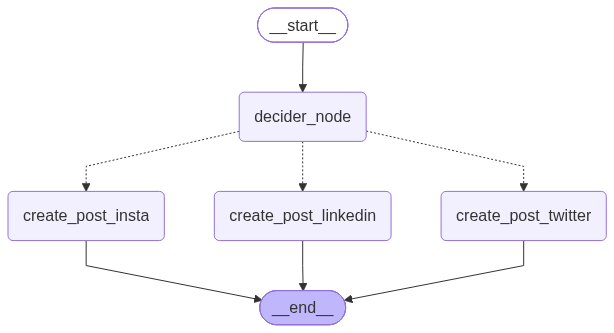

In [51]:
from IPython.display import display

display(routing_graph)

In [52]:
result = routing_graph.invoke({
    "input": "Write a post about the beauty of nature",
    "topic":"",
    "post":"",
    "category":""
})

result

TypeError: 'llm_schema' object is not subscriptable